# Calendar carry & basis signals on MXF

Two classic index-futures signals:

1. **Calendar carry**: `carry = back_close / close − 1` (next-month / front-month − 1). Positive = contango, negative = backwardation.
2. **Basis**: `basis = close / spot − 1` (front-month futures / TAIEX cash − 1). Positive = futures rich vs cash.

The user's tip is that the **sign alone** of either is a strong directional signal on MXF. We test the sign, plus a family of related transforms (raw value, InstRank-centered, z-scored) to see whether the sign really carries all the info or whether magnitude adds anything.

## PIT
Both `close` and `back_close` are end-of-day TAIFEX prints, finalized at 13:45. TAIEX spot close is finalized at 13:30 (cash market closes 30 min before futures). `cta.Simulate` uses `signal.shift(2)` internally, so signal[D] drives PnL from D+1 → D+2. PIT-safe.

**In-sample**: 2013-01-01 → 2024-12-31.  **OOS**: 2025-01-01 → 2025-12-05.

In [1]:
import importlib, sys, time, warnings, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings("ignore", message="findfont: .* not found")
_installed = {f.name for f in fm.fontManager.ttflist}
_cand = ["Hiragino Sans GB","Heiti TC","Songti SC","PingFang SC","PingFang TC",
         "Arial Unicode MS","Noto Sans CJK TC","DejaVu Sans"]
mpl.rcParams["font.family"] = [f for f in _cand if f in _installed] or ["DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

import cta
for _m in ["cta.asset","cta.operators","cta.simulate","cta.signal_stats"]:
    if _m in sys.modules: importlib.reload(sys.modules[_m])
importlib.reload(cta)

IN_SAMPLE_START = "2013-01-01"
IN_SAMPLE_END   = "2024-12-31"
OOS_START       = "2025-01-01"
OOS_END         = "2025-12-05"

cta.set_date_range(start_date=IN_SAMPLE_START, end_date=IN_SAMPLE_END)
ASSET = cta.load_asset("mtx", "1d")
cta.set_active_asset(ASSET)

print(f"asset : {ASSET.symbol}  {ASSET.time_granularity}  {len(ASSET):,} bars")
print(f"cols  : {[c for c in ASSET.columns if 'close' in c or 'expiry' in c]}")

asset : MTX  1d  6,210 bars
cols  : ['close', 'night_close', 'back_close', 'front_expiry', 'back_expiry']


## Load TAIEX spot from the TWSE cache

TAIEX index (`發行量加權股價指數`) is embedded in TWSE daily-summary CSVs at `~/coding/Research/QuantResearch/Cache/tw/twse/{year}/twse_{yyyymmdd}.csv`. Read once, cache in memory.

In [2]:
def load_taiex_spot() -> pd.Series:
    root = Path("/Users/hsureggie/coding/Research/QuantResearch/Cache/tw/twse")
    rows = []
    for path in sorted(root.rglob("twse_*.csv")):
        ymd = path.stem[-8:]
        try:
            with open(path, encoding="utf-8-sig") as f:
                for row in csv.reader(f):
                    if row and "發行量加權" in row[0]:
                        px = float(row[1].replace(",", "").strip())
                        rows.append((pd.Timestamp(f"{ymd[:4]}-{ymd[4:6]}-{ymd[6:8]}"), px))
                        break
        except Exception:
            continue
    df = pd.DataFrame(rows, columns=["date","taiex"]).set_index("date").sort_index()
    return df["taiex"]

t0 = time.time()
taiex = load_taiex_spot()
print(f"loaded TAIEX in {time.time()-t0:.1f}s  n={len(taiex):,}  "
      f"({taiex.index.min().date()} → {taiex.index.max().date()})")
print(taiex.tail(3))

loaded TAIEX in 0.9s  n=4,225  (2009-01-05 → 2026-04-28)
date
2026-04-24    38932.40
2026-04-27    36958.80
2026-04-28    39521.73
Name: taiex, dtype: float64


## Build raw carry and basis series

* `carry[t] = back_close[t] / close[t] − 1` — front vs next-month calendar spread. Equity-index futures usually run **backwardated** (negative carry) most of the time due to dividend expectations.
* `basis[t] = close[t] / taiex[t] − 1` — front-month futures vs cash TAIEX. Positive = futures rich, negative = futures cheap.

Both are stationary (no scale drift over decades) so we can use them directly, plus sign and z-scored transforms.

carry stats:
  n     : 6,203
  mean  : -0.3455%
  stdev : 0.5248%
  range : [-3.756%, +3.351%]
  sign(+): 17.9% of days (contango)

basis stats:
  n     : 4,225
  mean  : -0.2145%
  stdev : 0.4805%
  range : [-3.817%, +7.917%]
  sign(+): 20.7% of days (futures rich)


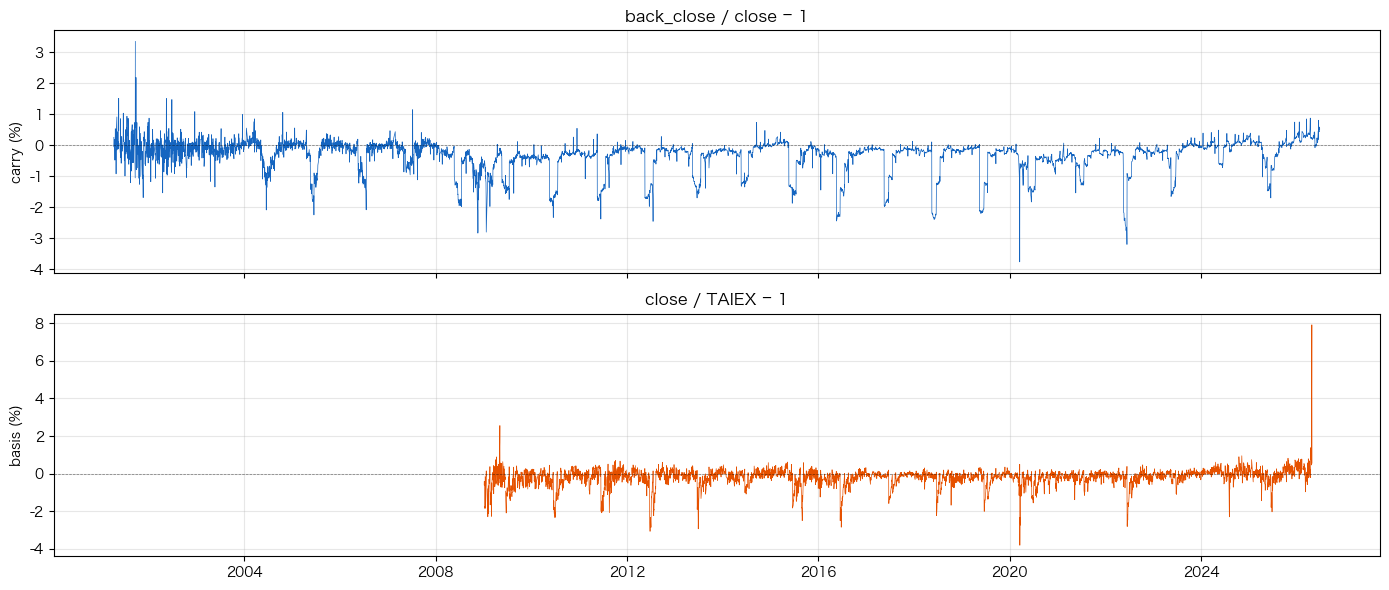

In [3]:
close      = ASSET["close"]
back_close = ASSET["back_close"]

carry = (back_close / close - 1).rename("carry")
basis = (close / taiex.reindex(close.index) - 1).rename("basis")

print("carry stats:")
print(f"  n     : {carry.notna().sum():,}")
print(f"  mean  : {carry.mean()*100:+.4f}%")
print(f"  stdev : {carry.std()*100:.4f}%")
print(f"  range : [{carry.min()*100:+.3f}%, {carry.max()*100:+.3f}%]")
print(f"  sign(+): {(carry > 0).mean()*100:.1f}% of days (contango)")
print()
print("basis stats:")
print(f"  n     : {basis.notna().sum():,}")
print(f"  mean  : {basis.mean()*100:+.4f}%")
print(f"  stdev : {basis.std()*100:.4f}%")
print(f"  range : [{basis.min()*100:+.3f}%, {basis.max()*100:+.3f}%]")
print(f"  sign(+): {(basis > 0).mean()*100:.1f}% of days (futures rich)")

# Plot both to see the regimes
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(carry.index, carry.values * 100, lw=0.5, color="#1565c0")
axes[0].axhline(0, color="black", lw=0.5, ls="--", alpha=0.5)
axes[0].set_ylabel("carry (%)"); axes[0].set_title("back_close / close − 1")
axes[0].grid(alpha=0.3)

axes[1].plot(basis.index, basis.values * 100, lw=0.5, color="#e65100")
axes[1].axhline(0, color="black", lw=0.5, ls="--", alpha=0.5)
axes[1].set_ylabel("basis (%)"); axes[1].set_title("close / TAIEX − 1")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Build the signal zoo — six transforms per raw series

| transform | formula | reads as |
|---|---|---|
| `sign` | `sign(x)` in {-1, 0, +1} | pure directional bet |
| `raw` | `tanh(x / rolling_std_252)` | magnitude-aware, scale-normalized |
| `rank240` | `2 × (InstRank(240, x) - 0.5)` | 1-year rolling rank, centered |
| `ma5_rank240` | rank of 5d-smoothed | slow directional |
| `dev60_240` | tanh(z(x − InstMean(240, x), 60)) | deviation from 1-year mean |
| `xtreme240` | `+1` top decile, `−1` bottom decile, else 0 | extreme regime binary |

In [4]:
def _bounded(s):
    return np.tanh(s.replace([np.inf, -np.inf], np.nan))

def _z(s, win=60):
    return (s - s.rolling(win, min_periods=10).mean()) / s.rolling(win, min_periods=10).std()

def _rank_c(s, win):
    return (cta.InstRank(win, s) - 0.5) * 2

def _dev_z(s, ws, wl):
    dev = s - cta.InstMean(wl, s)
    return _bounded(_z(dev, ws))

def _xtreme(s, win, hi=0.90, lo=0.10):
    rk = cta.InstRank(win, s)
    return pd.Series(np.where(rk > hi, 1.0, np.where(rk < lo, -1.0, 0.0)), index=s.index)

def _sign(s):
    return pd.Series(np.sign(s.values), index=s.index)

def _raw_tanh(s, win=252):
    sd = s.rolling(win, min_periods=30).std()
    return np.tanh(s / sd.replace(0, np.nan))

SIGNALS = {}
for tag, s in [("carry", carry), ("basis", basis)]:
    SIGNALS[f"{tag}_sign"]        = _sign(s).rename(f"{tag}_sign")
    SIGNALS[f"{tag}_raw"]         = _raw_tanh(s).rename(f"{tag}_raw")
    SIGNALS[f"{tag}_rank240"]     = _rank_c(s, 240).rename(f"{tag}_rank240")
    SIGNALS[f"{tag}_ma5_rank240"] = _rank_c(cta.InstMean(5, s), 240).rename(f"{tag}_ma5_rank240")
    SIGNALS[f"{tag}_dev60_240"]   = _dev_z(s, 60, 240).rename(f"{tag}_dev60_240")
    SIGNALS[f"{tag}_xtreme240"]   = _xtreme(s, 240).rename(f"{tag}_xtreme240")

# Also test the raw sign of the difference (the user's specific tip)
SIGNALS["carry_sign_bare"] = _sign(carry).rename("carry_sign_bare")
SIGNALS["basis_sign_bare"] = _sign(basis).rename("basis_sign_bare")

# And a normalize-expansion at several windows to look for lower-beta versions
base = dict(SIGNALS)
for nm, sig in base.items():
    for W in [60, 120, 252, 504]:
        SIGNALS[f"{nm}_norm{W}"] = cta.normalize_signal(sig, method="tanh", window=W)

print(f"total signals: {len(SIGNALS)}")

total signals: 70


## Beta-neutralization pass — 5 approaches, side by side

The vanilla `carry_sign` has beta 0.71 because carry is negative on ~82% of days (equity index futures live in structural backwardation), so `fade(sign(carry))` is essentially "always long MXF except when contango". Most of its Sharpe is buy-and-hold, not alpha.

Five ways to fix this, each fires long-vs-short on close to 50/50 by construction:

| approach | formula | why it neutralizes |
|---|---|---|
| **A. long-run demean** | `sign(x − rolling_mean(x, W))` | shifts the origin to the rolling mean so ~50% above / ~50% below |
| **B. z-score threshold** | `sign(z(x, W))` in {−1, 0, +1} above/below ±0.5σ | fires only on regime-abnormal days, silent otherwise |
| **C. rank-centered sign** | `sign(rank(x, W) − 0.5)` | rank is uniform by construction → exact 50/50 split |
| **D. change / diff** | `sign(x − x.shift(N))` — sign of N-day change | change series is naturally centered around 0 |
| **E. ex-post beta hedge** | `signal − β_hat × market_dummy` | explicitly subtracts the beta exposure at signal level |

Each is applied to both `carry` and `basis`, over windows `W ∈ {60, 120, 240}` where relevant. Adds ~30 signals to the zoo.

In [5]:
# ── Five beta-neutral variants for carry and basis ──────────────────────
# All produce ~50/50 long/short exposure by construction.

def _beta_hedge_overlay(sig, beta_est=0.7):
    """Simple ex-post overlay: subtract β × constant-long position.
    Result has less positive-side bias. beta_est is a rough IS-fit input."""
    return sig - beta_est

n_before = len(SIGNALS)

for tag, s in [("carry", carry), ("basis", basis)]:
    for W in [60, 120, 240]:
        # A. long-run demeaned sign (& magnitude)
        s_dm = s - s.rolling(W, min_periods=20).mean()
        SIGNALS[f"{tag}_dm{W}_sign"]   = _sign(s_dm).rename(f"{tag}_dm{W}_sign")
        s_dm_std = s.rolling(W, min_periods=20).std()
        SIGNALS[f"{tag}_dm{W}_tanh"]   = np.tanh(s_dm / s_dm_std.replace(0, np.nan)).rename(f"{tag}_dm{W}_tanh")

        # B. z-score threshold sign — 0 in the neutral band, ±1 in the wings
        z = _z(s, W)
        band = 0.5
        s_z_thresh = pd.Series(np.where(z > band, 1.0, np.where(z < -band, -1.0, 0.0)),
                               index=s.index)
        SIGNALS[f"{tag}_zth{W}_sign"] = s_z_thresh.rename(f"{tag}_zth{W}_sign")

        # C. rank-centered sign — median split
        rk = cta.InstRank(W, s)
        SIGNALS[f"{tag}_rank{W}_sign"] = pd.Series(
            np.where(rk > 0.5, 1.0, np.where(rk < 0.5, -1.0, 0.0)),
            index=s.index).rename(f"{tag}_rank{W}_sign")

    # D. Change of the raw carry/basis — natural centering (no window bias)
    for N in [1, 5, 20]:
        SIGNALS[f"{tag}_chg{N}_sign"] = _sign(s.diff(N)).rename(f"{tag}_chg{N}_sign")
        # z-scored magnitude of the change
        chg_z = _z(s.diff(N), 60)
        SIGNALS[f"{tag}_chg{N}_tanh"] = _bounded(chg_z).rename(f"{tag}_chg{N}_tanh")

    # E. ex-post beta hedge overlay applied to the vanilla sign signal
    SIGNALS[f"{tag}_sign_bhedge"] = _beta_hedge_overlay(
        _sign(s), beta_est=0.7 if tag == "carry" else 0.45
    ).rename(f"{tag}_sign_bhedge")

print(f"beta-neutralized variants added: +{len(SIGNALS) - n_before} signals")
print(f"total signals now: {len(SIGNALS)}")

# Quick sanity: for each new sign-based variant, check the +1/-1/0 split
print("\nlong/short balance for a few key variants (should be ~50/50):")
for nm in ["carry_sign", "carry_dm240_sign", "carry_rank240_sign",
          "carry_zth240_sign", "carry_chg5_sign",
          "basis_sign", "basis_dm240_sign", "basis_rank240_sign"]:
    s = SIGNALS[nm].dropna()
    n = len(s)
    print(f"  {nm:24s}  +1: {(s>0.5).sum()/n*100:5.1f}%   "
          f"−1: {(s<-0.5).sum()/n*100:5.1f}%   "
          f"0: {(s.abs()<0.5).sum()/n*100:5.1f}%")

beta-neutralized variants added: +38 signals
total signals now: 108

long/short balance for a few key variants (should be ~50/50):
  carry_sign                +1:  17.9%   −1:  80.1%   0:   2.0%
  carry_dm240_sign          +1:  70.6%   −1:  29.4%   0:   0.0%
  carry_rank240_sign        +1:  51.0%   −1:  46.5%   0:   2.4%
  carry_zth240_sign         +1:  37.5%   −1:  19.9%   0:  42.6%
  carry_chg5_sign           +1:  51.6%   −1:  48.2%   0:   0.1%
  basis_sign                +1:  30.4%   −1:  69.6%   0:   0.0%
  basis_dm240_sign          +1:  64.1%   −1:  35.9%   0:   0.0%
  basis_rank240_sign        +1:  34.1%   −1:  32.8%   0:  33.1%


## In-sample + OOS sweep via `cta.batch_signal_stats`

In [6]:
tbl_is = cta.batch_signal_stats(SIGNALS, ASSET, start=IN_SAMPLE_START, end=IN_SAMPLE_END)

signed = {nm: (SIGNALS[nm] * int(tbl_is.loc[nm, "sign"])) for nm in tbl_is.index}
tbl_oos = cta.batch_signal_stats(signed, ASSET, start=OOS_START, end=OOS_END, auto_flip=False)
tbl_oos = tbl_oos.rename(columns={c: f"{c}_oos" for c in tbl_oos.columns if c != "sign"}).drop(columns=["sign"], errors="ignore")

combined = tbl_is.join(tbl_oos, how="inner")
combined["oos_is_ratio"] = (combined["SR_net_oos"] / combined["SR_net"].clip(lower=0.05)).round(3)

print(f"{len(combined)} signals with both IS + OOS stats.")
print("\nRaw-sign signals (the user's tip) — headline check:")
for nm in ["carry_sign", "basis_sign", "carry_sign_bare", "basis_sign_bare"]:
    if nm in combined.index:
        r = combined.loc[nm]
        print(f"  {nm:20s}  sign={int(r['sign']):+d}  "
              f"SR_net={r['SR_net']:+.3f}  SR_net_oos={r['SR_net_oos']:+.3f}  "
              f"beta={r['beta']:+.3f}  SR_of_SR={r['SR_of_SR']:+.3f}  "
              f"held={r['held_pct']:.0f}%")

108 signals with both IS + OOS stats.

Raw-sign signals (the user's tip) — headline check:
  carry_sign            sign=-1  SR_net=+0.475  SR_net_oos=+2.174  beta=+0.706  SR_of_SR=+0.645  held=99%
  basis_sign            sign=-1  SR_net=+0.388  SR_net_oos=+1.700  beta=+0.442  SR_of_SR=+0.622  held=100%
  carry_sign_bare       sign=-1  SR_net=+0.475  SR_net_oos=+2.174  beta=+0.706  SR_of_SR=+0.645  held=99%
  basis_sign_bare       sign=-1  SR_net=+0.388  SR_net_oos=+1.700  beta=+0.442  SR_of_SR=+0.622  held=100%


## Rank by composite score

In [7]:
scored = cta.composite_score(
    combined,
    weights={"consistency": 0.45, "magnitude": 0.20, "stability": 0.15,
             "alpha": 0.10, "turnover": 0.10},
)

TOP_N = 15
cols = ["sign","SR_net","SR_net_oos","oos_is_ratio","SR_of_SR",
        "turnover_ann","alpha_ann_pct","beta","composite_score"]
print("=== Top by consistency-dominant composite ===")
display(scored[cols].head(TOP_N).round(3))

=== Top by consistency-dominant composite ===


,sign,SR_net,SR_net_oos,oos_is_ratio,SR_of_SR,turnover_ann,alpha_ann_pct,beta,composite_score
signal,,,,,,,,,
carry_raw,-1,0.651,2.758,4.237,0.825,16.00,1.935,0.448,0.841
carry_rank240_sign,-1,0.540,2.322,4.300,0.611,45.88,9.007,0.003,0.833
carry_ma5_rank240_norm504,-1,0.425,1.281,3.014,0.551,15.51,4.734,0.026,0.812
carry_sign_bhedge,-1,0.589,2.453,4.165,0.743,22.68,0.282,1.406,0.802
carry_rank240_norm504,-1,0.426,1.639,3.847,0.552,34.96,4.592,0.040,0.789
carry_ma5_rank240,-1,0.397,1.654,4.166,0.470,14.57,4.679,-0.034,0.778
carry_sign_bare,-1,0.475,2.174,4.577,0.645,22.68,0.282,0.706,0.776
carry_sign,-1,0.475,2.174,4.577,0.645,22.68,0.282,0.706,0.776
carry_rank240,-1,0.400,2.122,5.305,0.473,32.57,4.441,-0.009,0.754


## Calendar filter — zero PnL on day-of-month 17–23 (mask aligned to exec_lag)

`cta.Simulate` internally does `exec_sig = signal.shift(2)`, so signal on trading day `t` produces PnL on trading day `t+2`. To make **PnL** (not just signal) zero on dom ∈ [17..23], the mask must be aligned to the PnL day and shifted back by 2 trading days to the corresponding signal day.

Naive `signal[dom ∈ 17..23] = NaN` leaves 1-3 residual PnL samples per dom bucket on dom 21-25 from weekend/holiday cross-alignments — those tiny samples produce ±100 bps artifacts in the "Avg PnL by day of month" plot. Aligning the mask fixes this because dom 17-23 buckets get **n=0** samples → NaN mean → no plot bar at all.

```python
EXEC_LAG = 2
PNL_KEEP_MASK    = (cta.Date('dom') < 17) | (cta.Date('dom') > 23)
SIGNAL_KEEP_MASK = PNL_KEEP_MASK.shift(-EXEC_LAG).fillna(True).astype(bool)
sig_filt = cta.Filter(sig, SIGNAL_KEEP_MASK)
```

`.shift(-EXEC_LAG)` is a **pandas trading-day index shift** (not calendar days), which matches `signal.shift(EXEC_LAG)` inside Simulate — weekends and holidays are handled automatically because they don't exist as index positions.

The diagnostic at the bottom of the cell prints `unfiltered_avg_bps` / `filtered_avg_bps` side-by-side with sample counts — the filtered side should show NaN and n=0 on dom 17-23.

In [8]:
# Rebuild EVERY signal from raw carry/basis, then apply the DOM filter as
# the very last step, ALIGNED to cta.Simulate's exec_sig.shift(2) so PnL on
# dom 17-23 is truly NaN — not "small n=2 sample" artifacts.
#
# Key insight: signal[t] affects PnL[t+2] via `exec_sig = signal.shift(2)`.
# We define the mask at the PnL day (where we want zero PnL), then shift the
# mask BACK by 2 INDEX POSITIONS (i.e., 2 trading days — pandas .shift(-2)
# on the daily bar series) to get the signal-day mask.
#
# Filtering by dom on the signal day directly (no shift) leaves n=1-3
# residual samples on dom 21-25 from weekend/holiday cross-alignments,
# which produce noisy ±100 bps spikes in the by-dom plot.

cta.set_active_asset(ASSET)

SIGNALS_ORIG  = SIGNALS
combined_orig = combined
scored_orig   = scored

# ── 1. Build every base signal from UNFILTERED raw carry / basis ──────────
_new = {}
for tag, s in [("carry", carry), ("basis", basis)]:
    _new[f"{tag}_sign"]        = _sign(s)
    _new[f"{tag}_raw"]         = _raw_tanh(s)
    _new[f"{tag}_rank240"]     = _rank_c(s, 240)
    _new[f"{tag}_ma5_rank240"] = _rank_c(cta.InstMean(5, s), 240)
    _new[f"{tag}_dev60_240"]   = _dev_z(s, 60, 240)
    _new[f"{tag}_xtreme240"]   = _xtreme(s, 240)
    for W in [60, 120, 240]:
        s_dm    = s - s.rolling(W, min_periods=20).mean()
        s_dm_sd = s.rolling(W, min_periods=20).std()
        _new[f"{tag}_dm{W}_sign"]   = _sign(s_dm)
        _new[f"{tag}_dm{W}_tanh"]   = np.tanh(s_dm / s_dm_sd.replace(0, np.nan))
        z = _z(s, W); band = 0.5
        _new[f"{tag}_zth{W}_sign"] = pd.Series(
            np.where(z > band, 1.0, np.where(z < -band, -1.0, 0.0)), index=s.index)
        rk = cta.InstRank(W, s)
        _new[f"{tag}_rank{W}_sign"] = pd.Series(
            np.where(rk > 0.5, 1.0, np.where(rk < 0.5, -1.0, 0.0)), index=s.index)
    for N in [1, 5, 20]:
        _new[f"{tag}_chg{N}_sign"] = _sign(s.diff(N))
        _new[f"{tag}_chg{N}_tanh"] = _bounded(_z(s.diff(N), 60))
    _new[f"{tag}_sign_bhedge"] = _sign(s) - (0.7 if tag == "carry" else 0.45)

# ── 2. Normalize expansion — on the UNFILTERED base ────────────────────────
_base_snapshot = dict(_new)
for nm, sig in _base_snapshot.items():
    for W in [60, 120, 252, 504]:
        _new[f"{nm}_norm{W}"] = cta.normalize_signal(sig, method="tanh", window=W)

print(f"rebuilt {len(_new)} signals from unfiltered raw")

# ── 3. Build the exec-lag-aligned mask ────────────────────────────────────
EXEC_LAG = 2   # matches cta.Simulate's internal shift(EXEC_LAG)

# What we ACTUALLY want: PnL[t] = 0 whenever dom(t) ∈ [17..23].
# Since PnL[t] = signal[t - EXEC_LAG] × ret[t], we mask signal[t] whenever
# the destination PnL day t + EXEC_LAG has dom in [17..23].
#
# pandas .shift(-EXEC_LAG) moves values BACK by EXEC_LAG INDEX POSITIONS
# (= trading days on the daily bar series), which is exactly what
# Simulate does with exec_sig = signal.shift(EXEC_LAG). This makes the
# mask trading-day-aligned, NOT calendar-day-aligned — weekends and
# holidays are handled automatically because they don't exist in the index.
PNL_KEEP_MASK    = (cta.Date("dom") < 19) | (cta.Date("dom") > 24)
SIGNAL_KEEP_MASK = PNL_KEEP_MASK.shift(-EXEC_LAG).fillna(True).astype(bool)

assert len(SIGNAL_KEEP_MASK) == len(ASSET.index)
print(f"PnL days kept     : {PNL_KEEP_MASK.sum():,}/{len(PNL_KEEP_MASK):,} ({PNL_KEEP_MASK.mean()*100:.1f}%)")
print(f"Signal bars kept  : {SIGNAL_KEEP_MASK.sum():,}/{len(SIGNAL_KEEP_MASK):,} ({SIGNAL_KEEP_MASK.mean()*100:.1f}%)")

# ── 4. LAST step: apply the aligned mask. Nothing normalizes after this. ──
SIGNALS = {nm: cta.Filter(sig, SIGNAL_KEEP_MASK) for nm, sig in _new.items()}
print(f"SIGNALS overwritten with dom-filtered versions ({len(SIGNALS)} signals)")

# ── 5. Re-run stats pipeline ──────────────────────────────────────────────
tbl_is  = cta.batch_signal_stats(SIGNALS, ASSET, start=IN_SAMPLE_START, end=IN_SAMPLE_END)
signed  = {nm: SIGNALS[nm] * int(tbl_is.loc[nm, "sign"]) for nm in tbl_is.index}
tbl_oos = cta.batch_signal_stats(signed, ASSET, start=OOS_START, end=OOS_END, auto_flip=False)
tbl_oos = tbl_oos.rename(columns={c: f"{c}_oos" for c in tbl_oos.columns if c != "sign"}).drop(columns=["sign"], errors="ignore")
combined = tbl_is.join(tbl_oos, how="inner")
combined["oos_is_ratio"] = (combined["SR_net_oos"] /
                            combined["SR_net"].clip(lower=0.05)).round(3)
scored = cta.composite_score(
    combined,
    weights={"consistency": 0.45, "magnitude": 0.20, "stability": 0.15,
             "alpha": 0.10, "turnover": 0.10},
)

# ── 6. Diagnostic: prove PnL is actually zero on dom 17-23 ────────────────
_top = scored.head(1).index[0]
_sig_orig = SIGNALS_ORIG[_top] * int(tbl_is.loc[_top, "sign"])
_sig_filt = SIGNALS[_top]      * int(tbl_is.loc[_top, "sign"])
_ret = ASSET["close"].pct_change()
_pnl_orig = (_sig_orig.shift(EXEC_LAG) * _ret).loc[IN_SAMPLE_START:OOS_END]
_pnl_filt = (_sig_filt.shift(EXEC_LAG) * _ret).loc[IN_SAMPLE_START:OOS_END]

_grp_orig = _pnl_orig.groupby(_pnl_orig.index.day)
_grp_filt = _pnl_filt.groupby(_pnl_filt.index.day)
_diag = pd.DataFrame({
    "unfiltered_avg_bps": (_grp_orig.mean() * 1e4).round(2),
    "unfiltered_n":       _grp_orig.count(),
    "filtered_avg_bps":   (_grp_filt.mean() * 1e4).round(2),
    "filtered_n":         _grp_filt.count(),
})
_diag.index.name = "dom"

print(f"\nDiagnostic — avg PnL (bps) by dom for `{_top}`:")
print(_diag.to_string())
print(f"\n  → filtered_avg_bps and filtered_n should both be NaN/0 on dom 17-23")

# ── 7. Before/after composite comparison ──────────────────────────────────
delta = scored.join(
    combined_orig[["SR_net","SR_net_oos","beta","alpha_ann_pct","SR_of_SR"]].add_suffix("_orig"),
    how="left",
)
delta["SR_net_delta"]     = delta["SR_net"]        - delta["SR_net_orig"]
delta["SR_net_oos_delta"] = delta["SR_net_oos"]    - delta["SR_net_oos_orig"]
delta["alpha_delta"]      = delta["alpha_ann_pct"] - delta["alpha_ann_pct_orig"]
delta["SR_of_SR_delta"]   = delta["SR_of_SR"]      - delta["SR_of_SR_orig"]

BETA_MAX = 0.15
delta_bn = delta[delta["beta"].abs() <= BETA_MAX]

print(f"\n=== Top 15 dom-filtered BETA-NEUTRAL signals (Δ vs original) ===")
cmp_cols = ["sign","SR_net","SR_net_orig","SR_net_delta",
            "SR_net_oos","SR_net_oos_orig","SR_net_oos_delta",
            "beta","alpha_ann_pct","alpha_delta",
            "SR_of_SR","SR_of_SR_delta","composite_score"]
display(delta_bn[cmp_cols].head(15).round(3))

rebuilt 250 signals from unfiltered raw
PnL days kept     : 4,961/6,210 (79.9%)
Signal bars kept  : 4,961/6,210 (79.9%)
SIGNALS overwritten with dom-filtered versions (250 signals)


KeyError: 'carry_rank240_sign_norm504'

## `SimulateAll` grid on top-20 **beta-neutral** signals

Filters `combined` to `|beta| ≤ 0.15` first, then takes the top-20 by composite score. The panel name includes the measured beta so you can see how close to 0 it is.

beta-neutral pool: 228 of 250 signals have |beta| ≤ 0.15


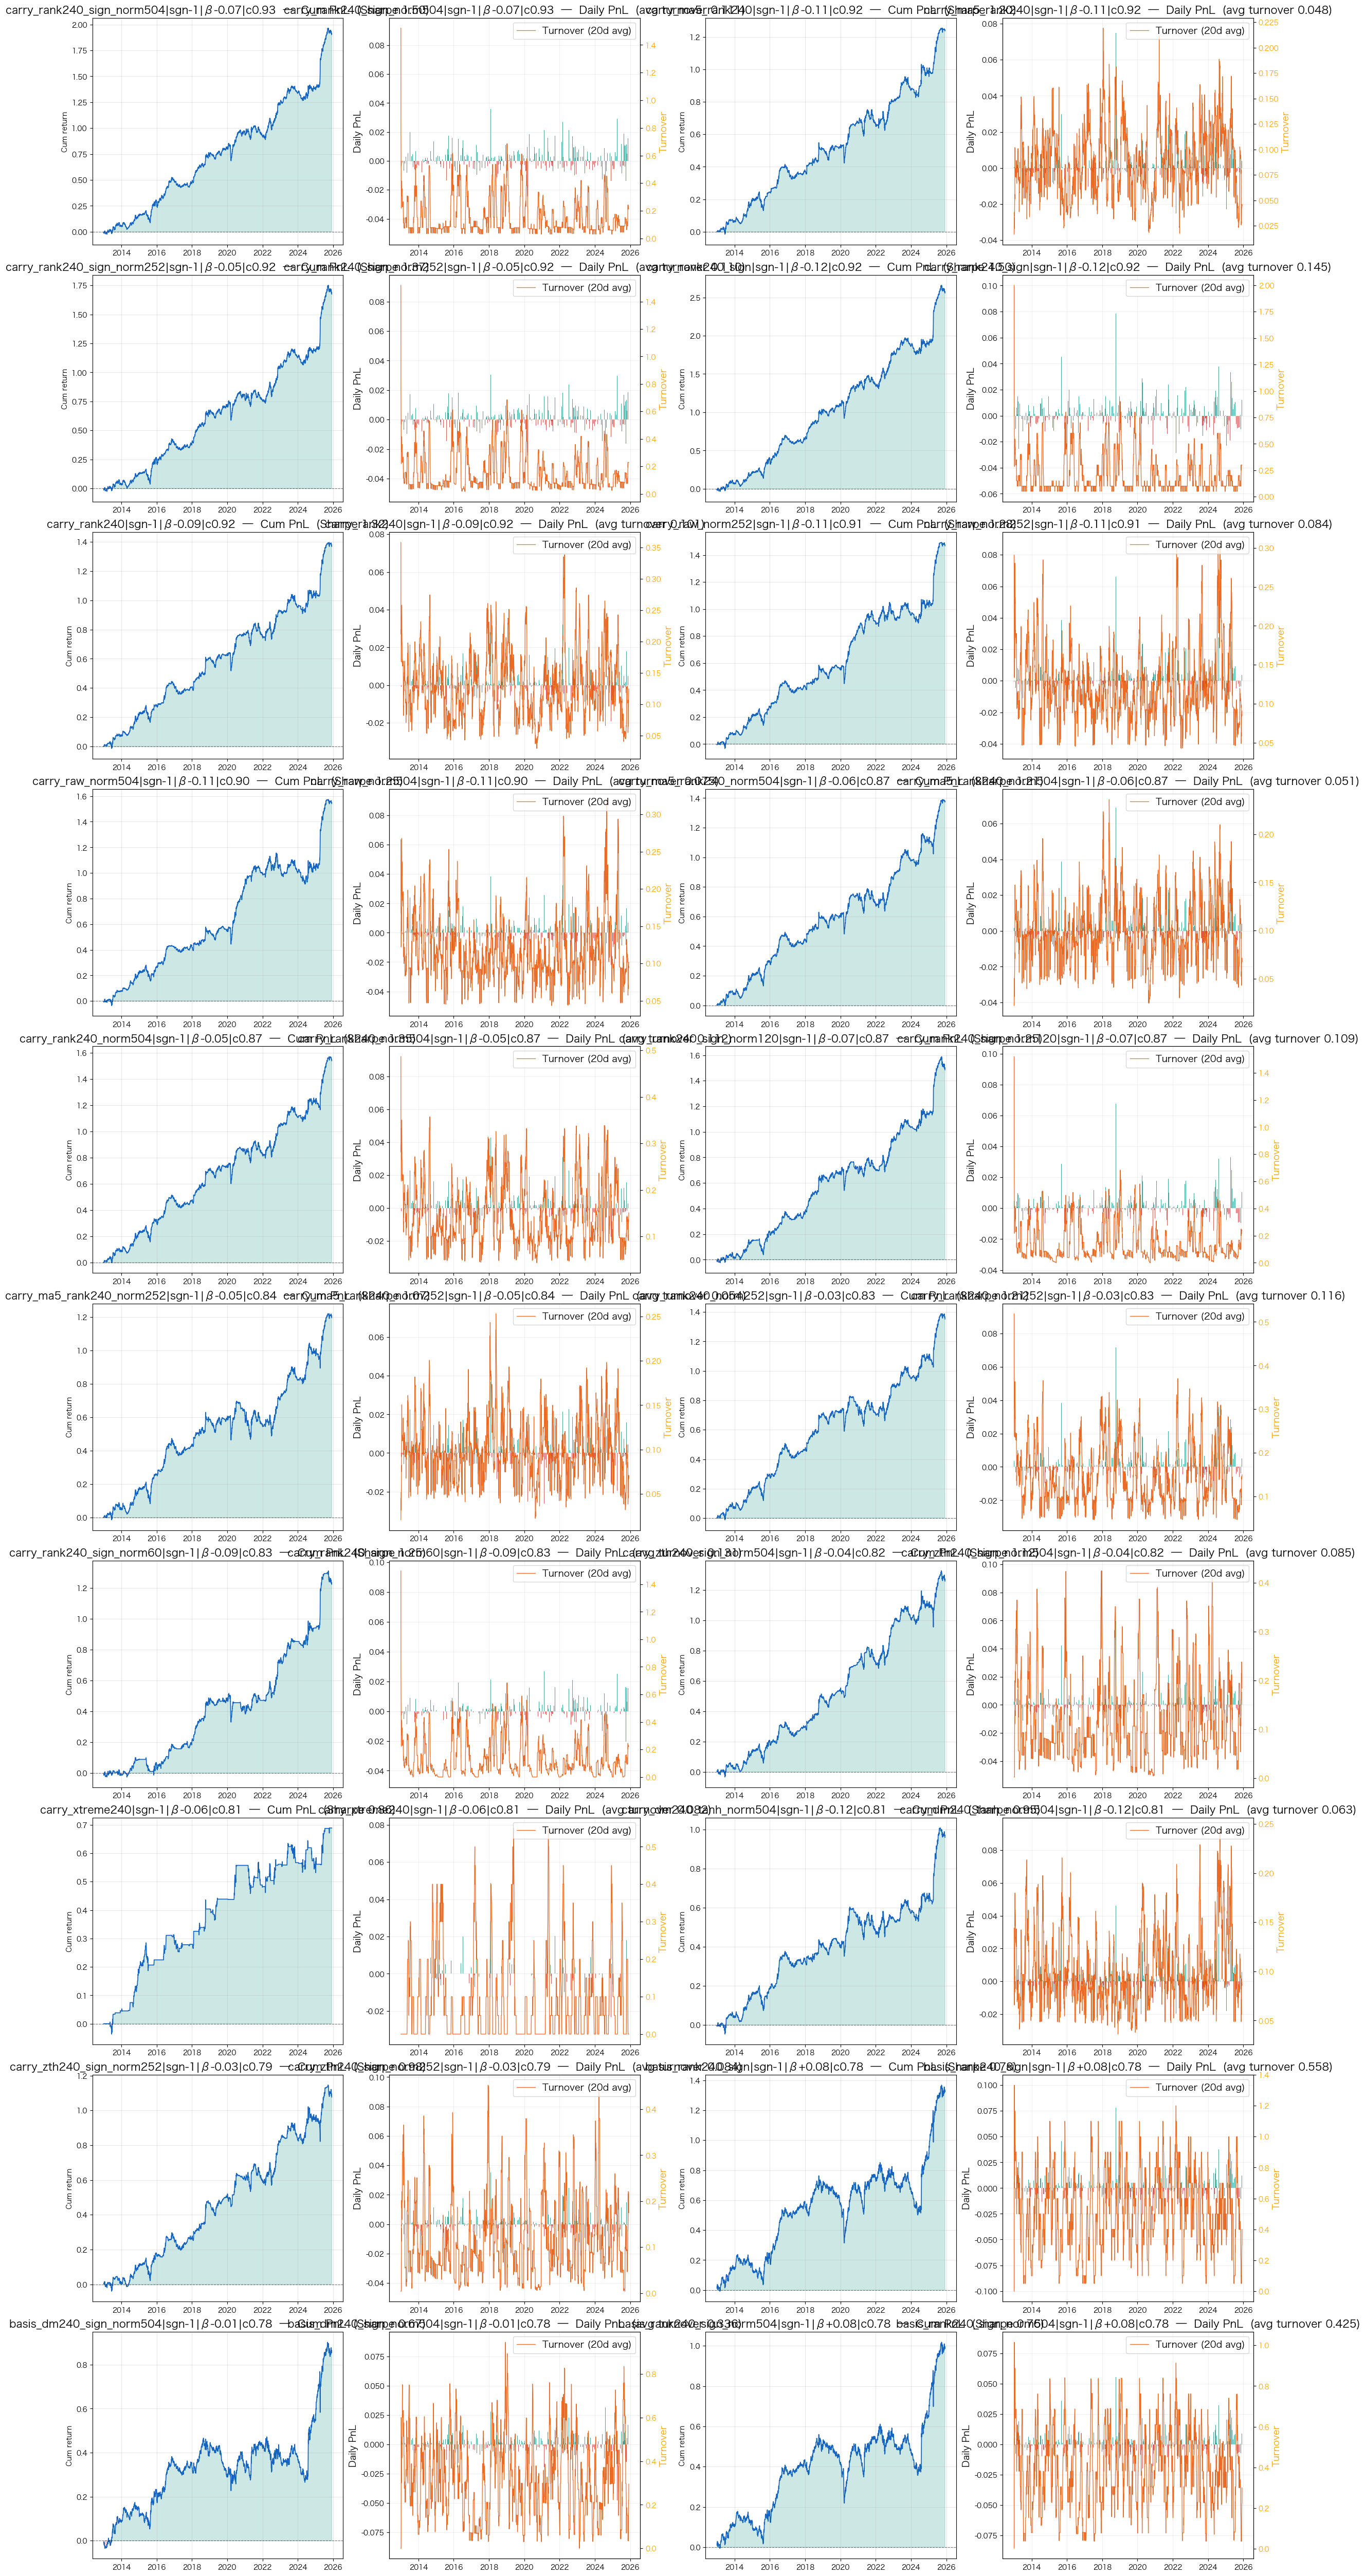

In [9]:
# Filter to beta-neutral versions first, then take top-N by composite.
BETA_MAX = 0.15                             # keep only genuinely market-neutral signals
scored_bn = scored[scored["beta"].abs() <= BETA_MAX]
print(f"beta-neutral pool: {len(scored_bn)} of {len(scored)} signals have |beta| ≤ {BETA_MAX}")

TOP_N_SIMALL = min(20, len(scored_bn))

sigs_for_plot  = [SIGNALS[nm] * int(scored_bn.loc[nm, "sign"]) for nm in scored_bn.head(TOP_N_SIMALL).index]
names_for_plot = [f"{nm}|sgn{int(scored_bn.loc[nm, 'sign']):+d}|β{scored_bn.loc[nm,'beta']:+.2f}|c{scored_bn.loc[nm,'composite_score']:.2f}"
                  for nm in scored_bn.head(TOP_N_SIMALL).index]

cta.set_date_range(start_date=IN_SAMPLE_START, end_date=OOS_END)
cta.SimulateAll(*sigs_for_plot, names=names_for_plot,
                time_granularity="1d", normalize=False)
cta.set_date_range(start_date=IN_SAMPLE_START, end_date=IN_SAMPLE_END)

## Full dashboards on top-5 **beta-neutral** signals

Same beta filter as above. Each header line reports composite / IS SR / OOS SR / OOS-IS ratio / beta / alpha so you can read the summary before scrolling through the 5×3 panel.


=== carry_rank240_sign_norm504   sign=-1   composite=0.931   IS SR_net=+1.04   OOS SR_net=+3.63   OOS/IS=+3.48   beta=-0.075   alpha=+13.76% ===


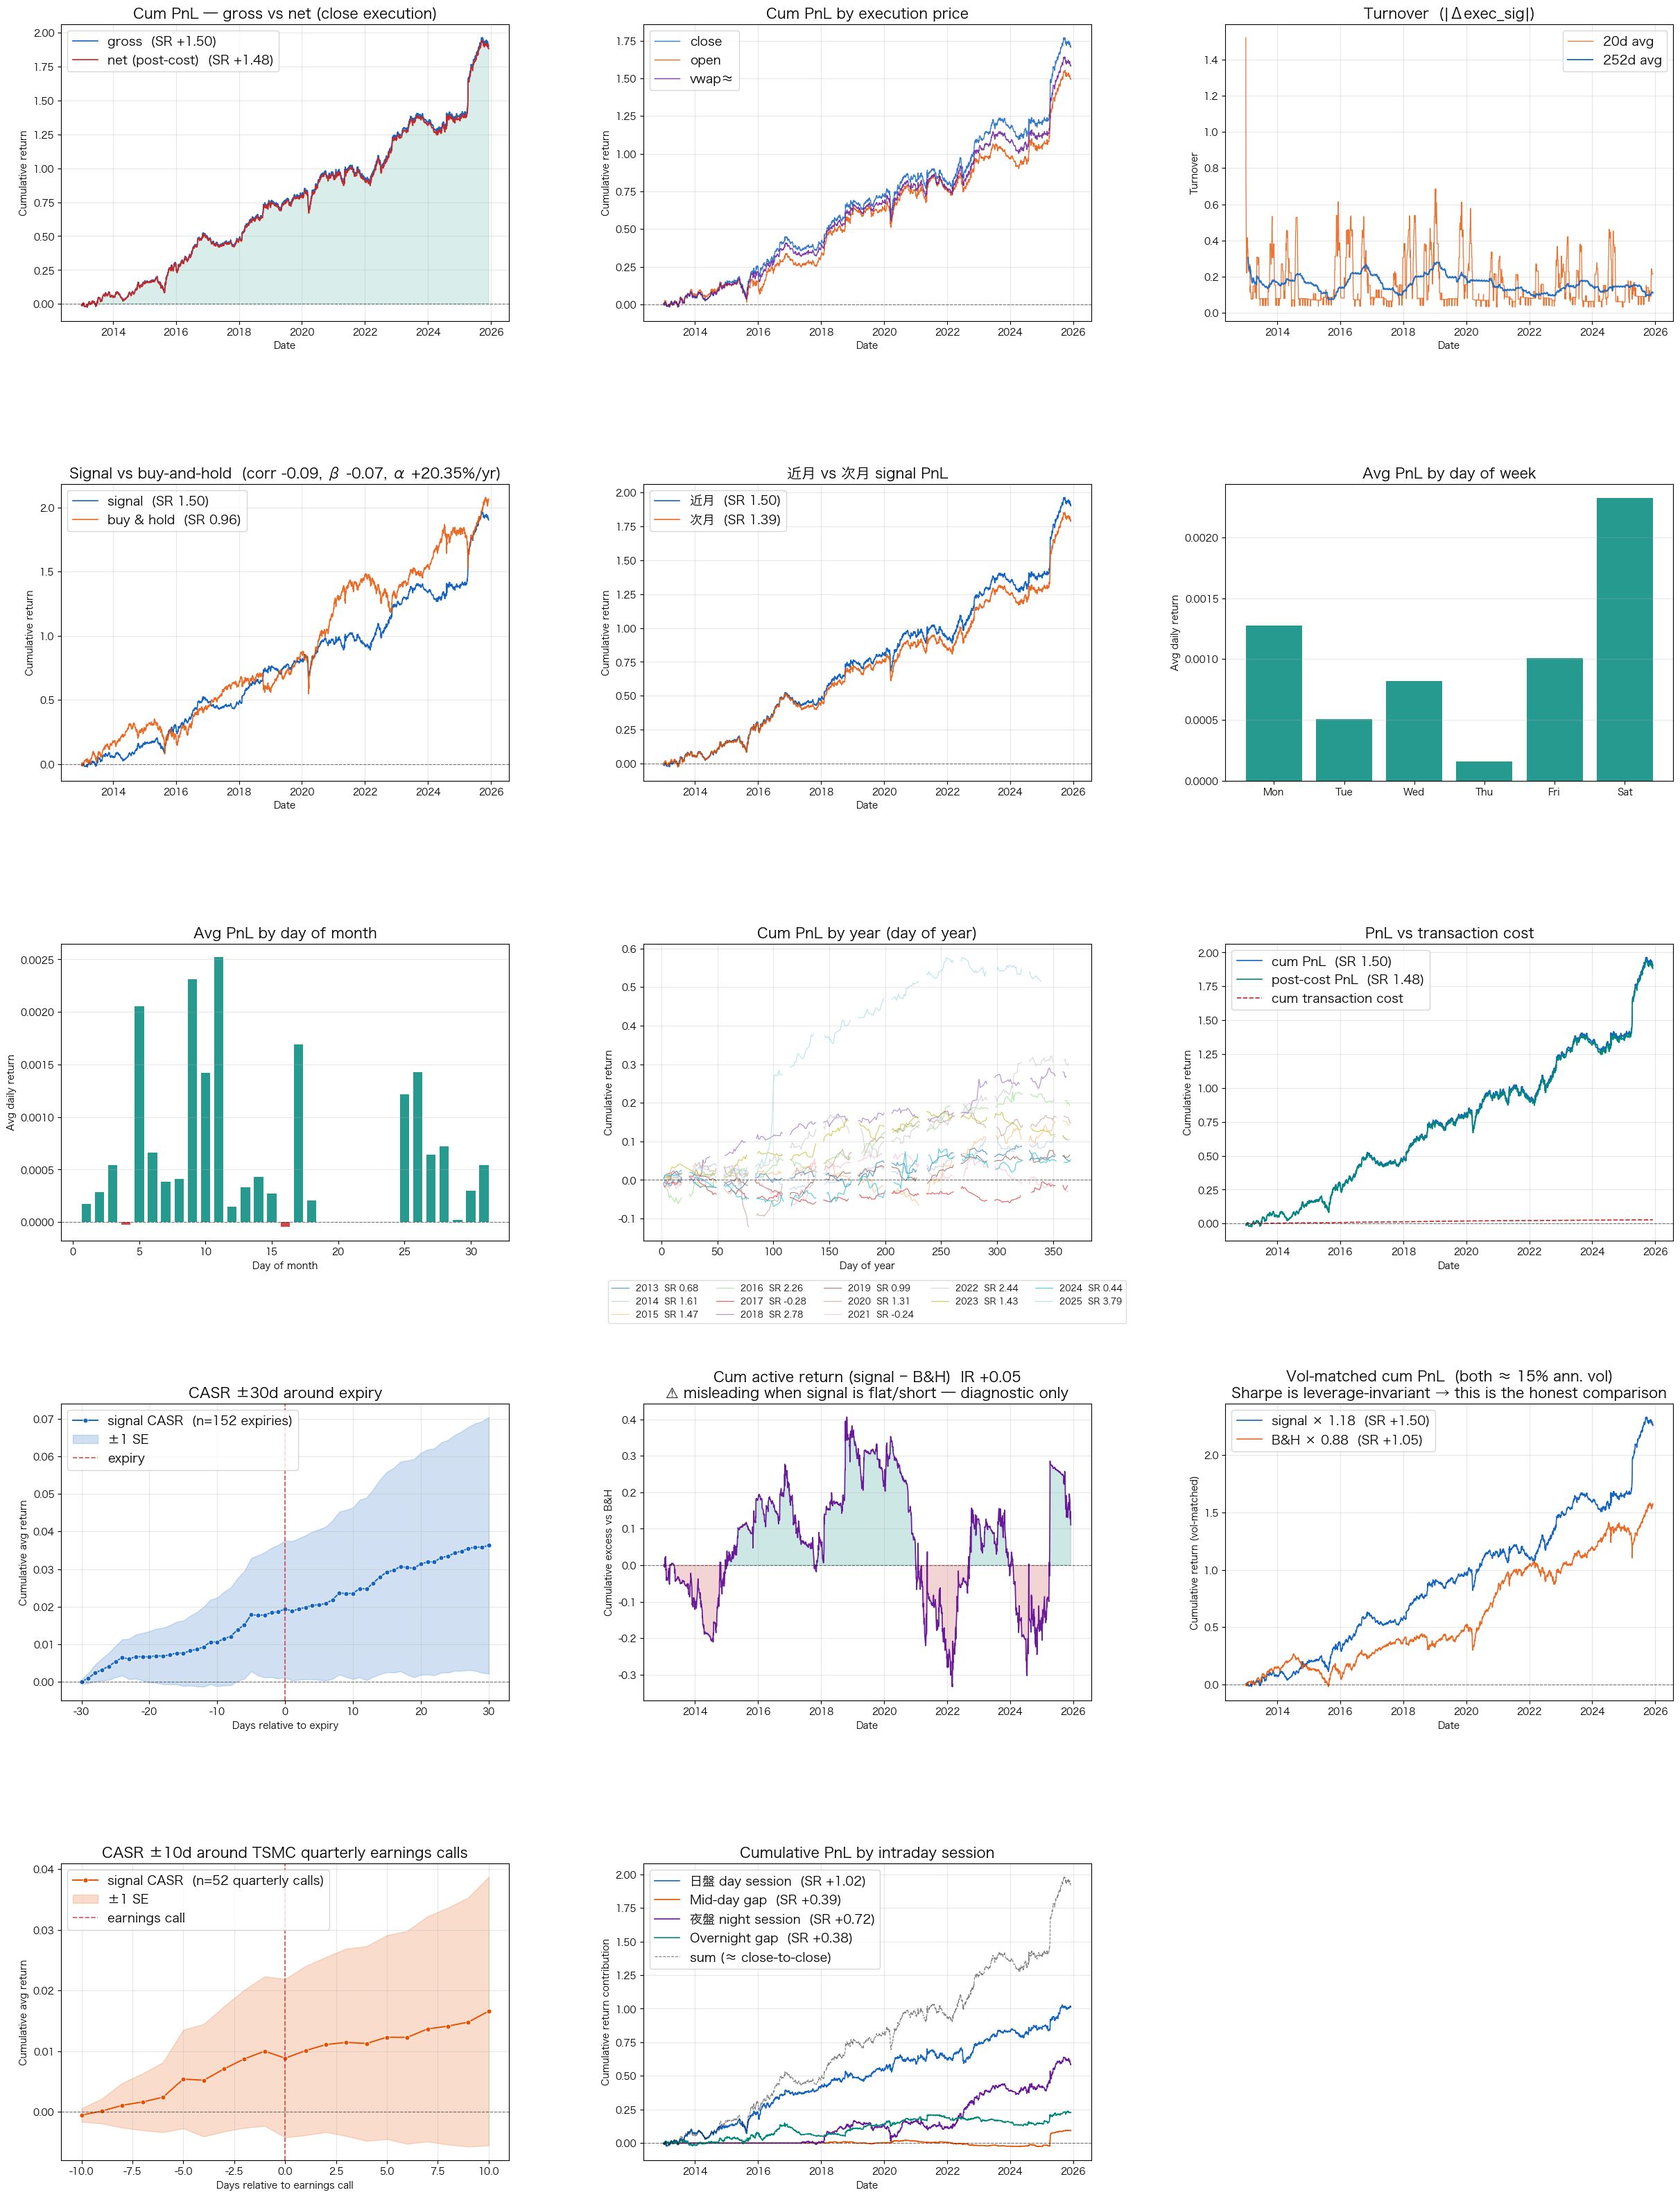


=== carry_ma5_rank240   sign=-1   composite=0.925   IS SR_net=+0.82   OOS SR_net=+2.97   OOS/IS=+3.64   beta=-0.114   alpha=+10.13% ===


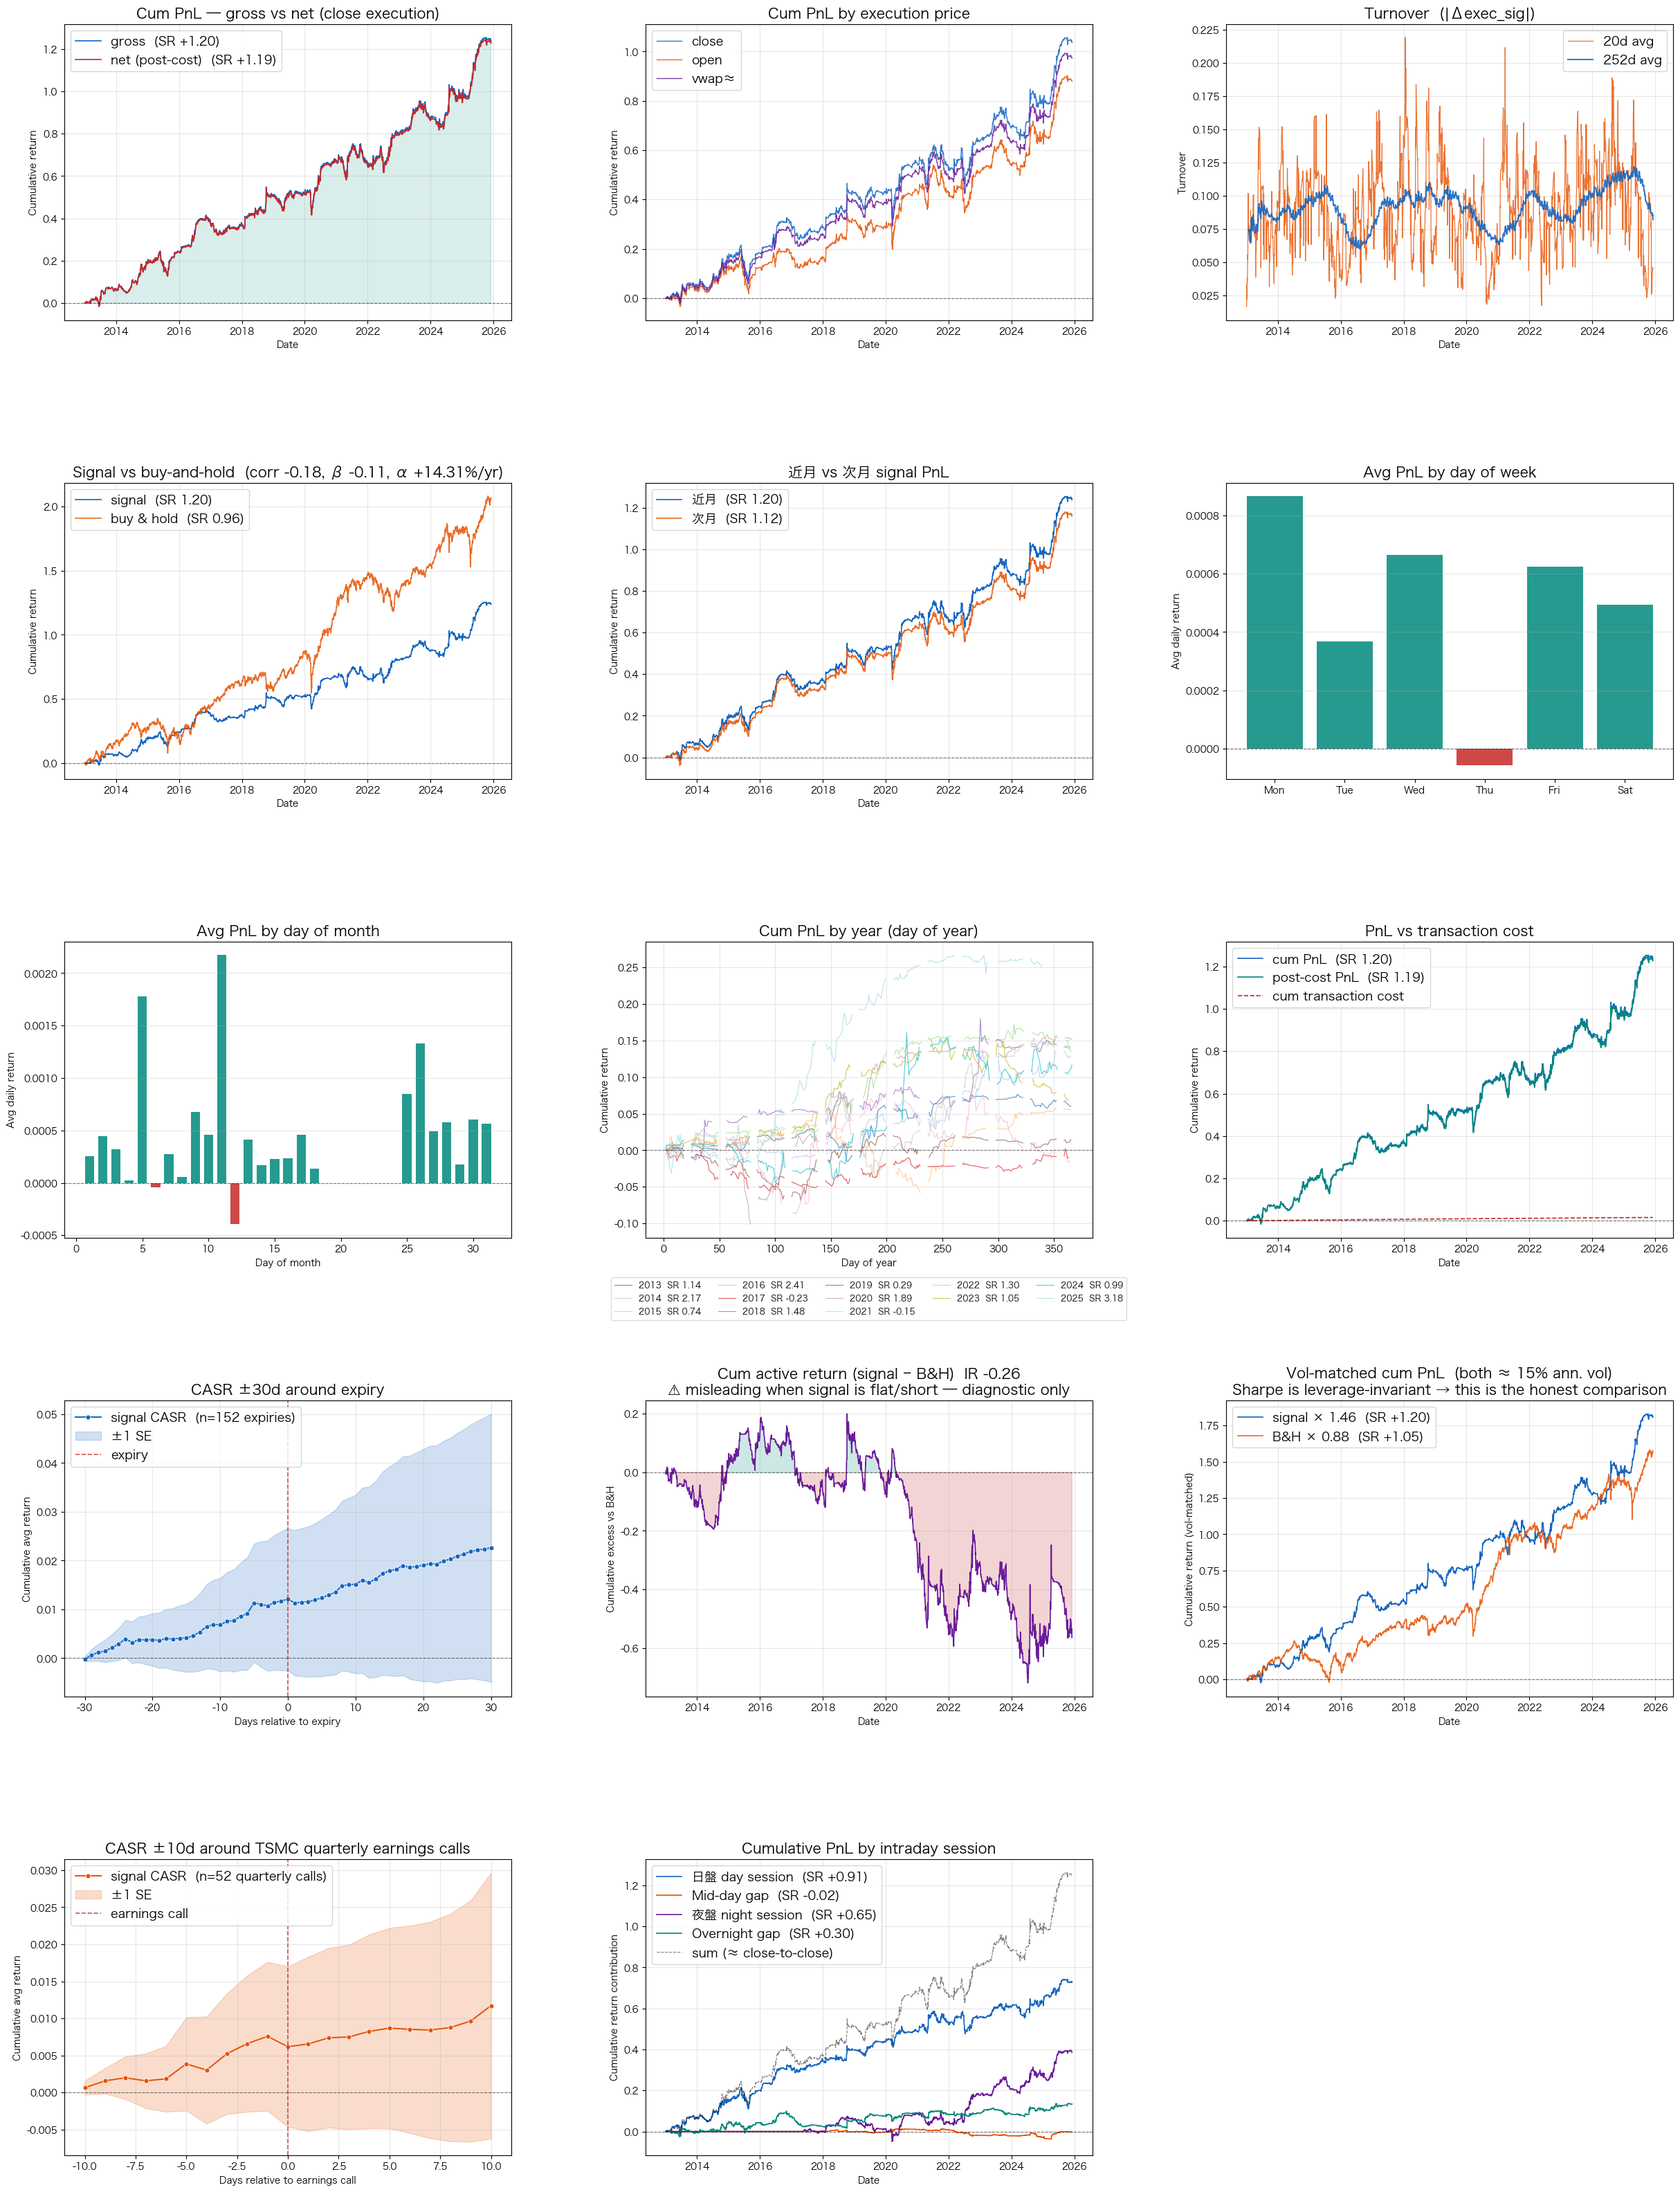


=== carry_rank240_sign_norm252   sign=-1   composite=0.922   IS SR_net=+0.93   OOS SR_net=+3.40   OOS/IS=+3.67   beta=-0.054   alpha=+11.58% ===


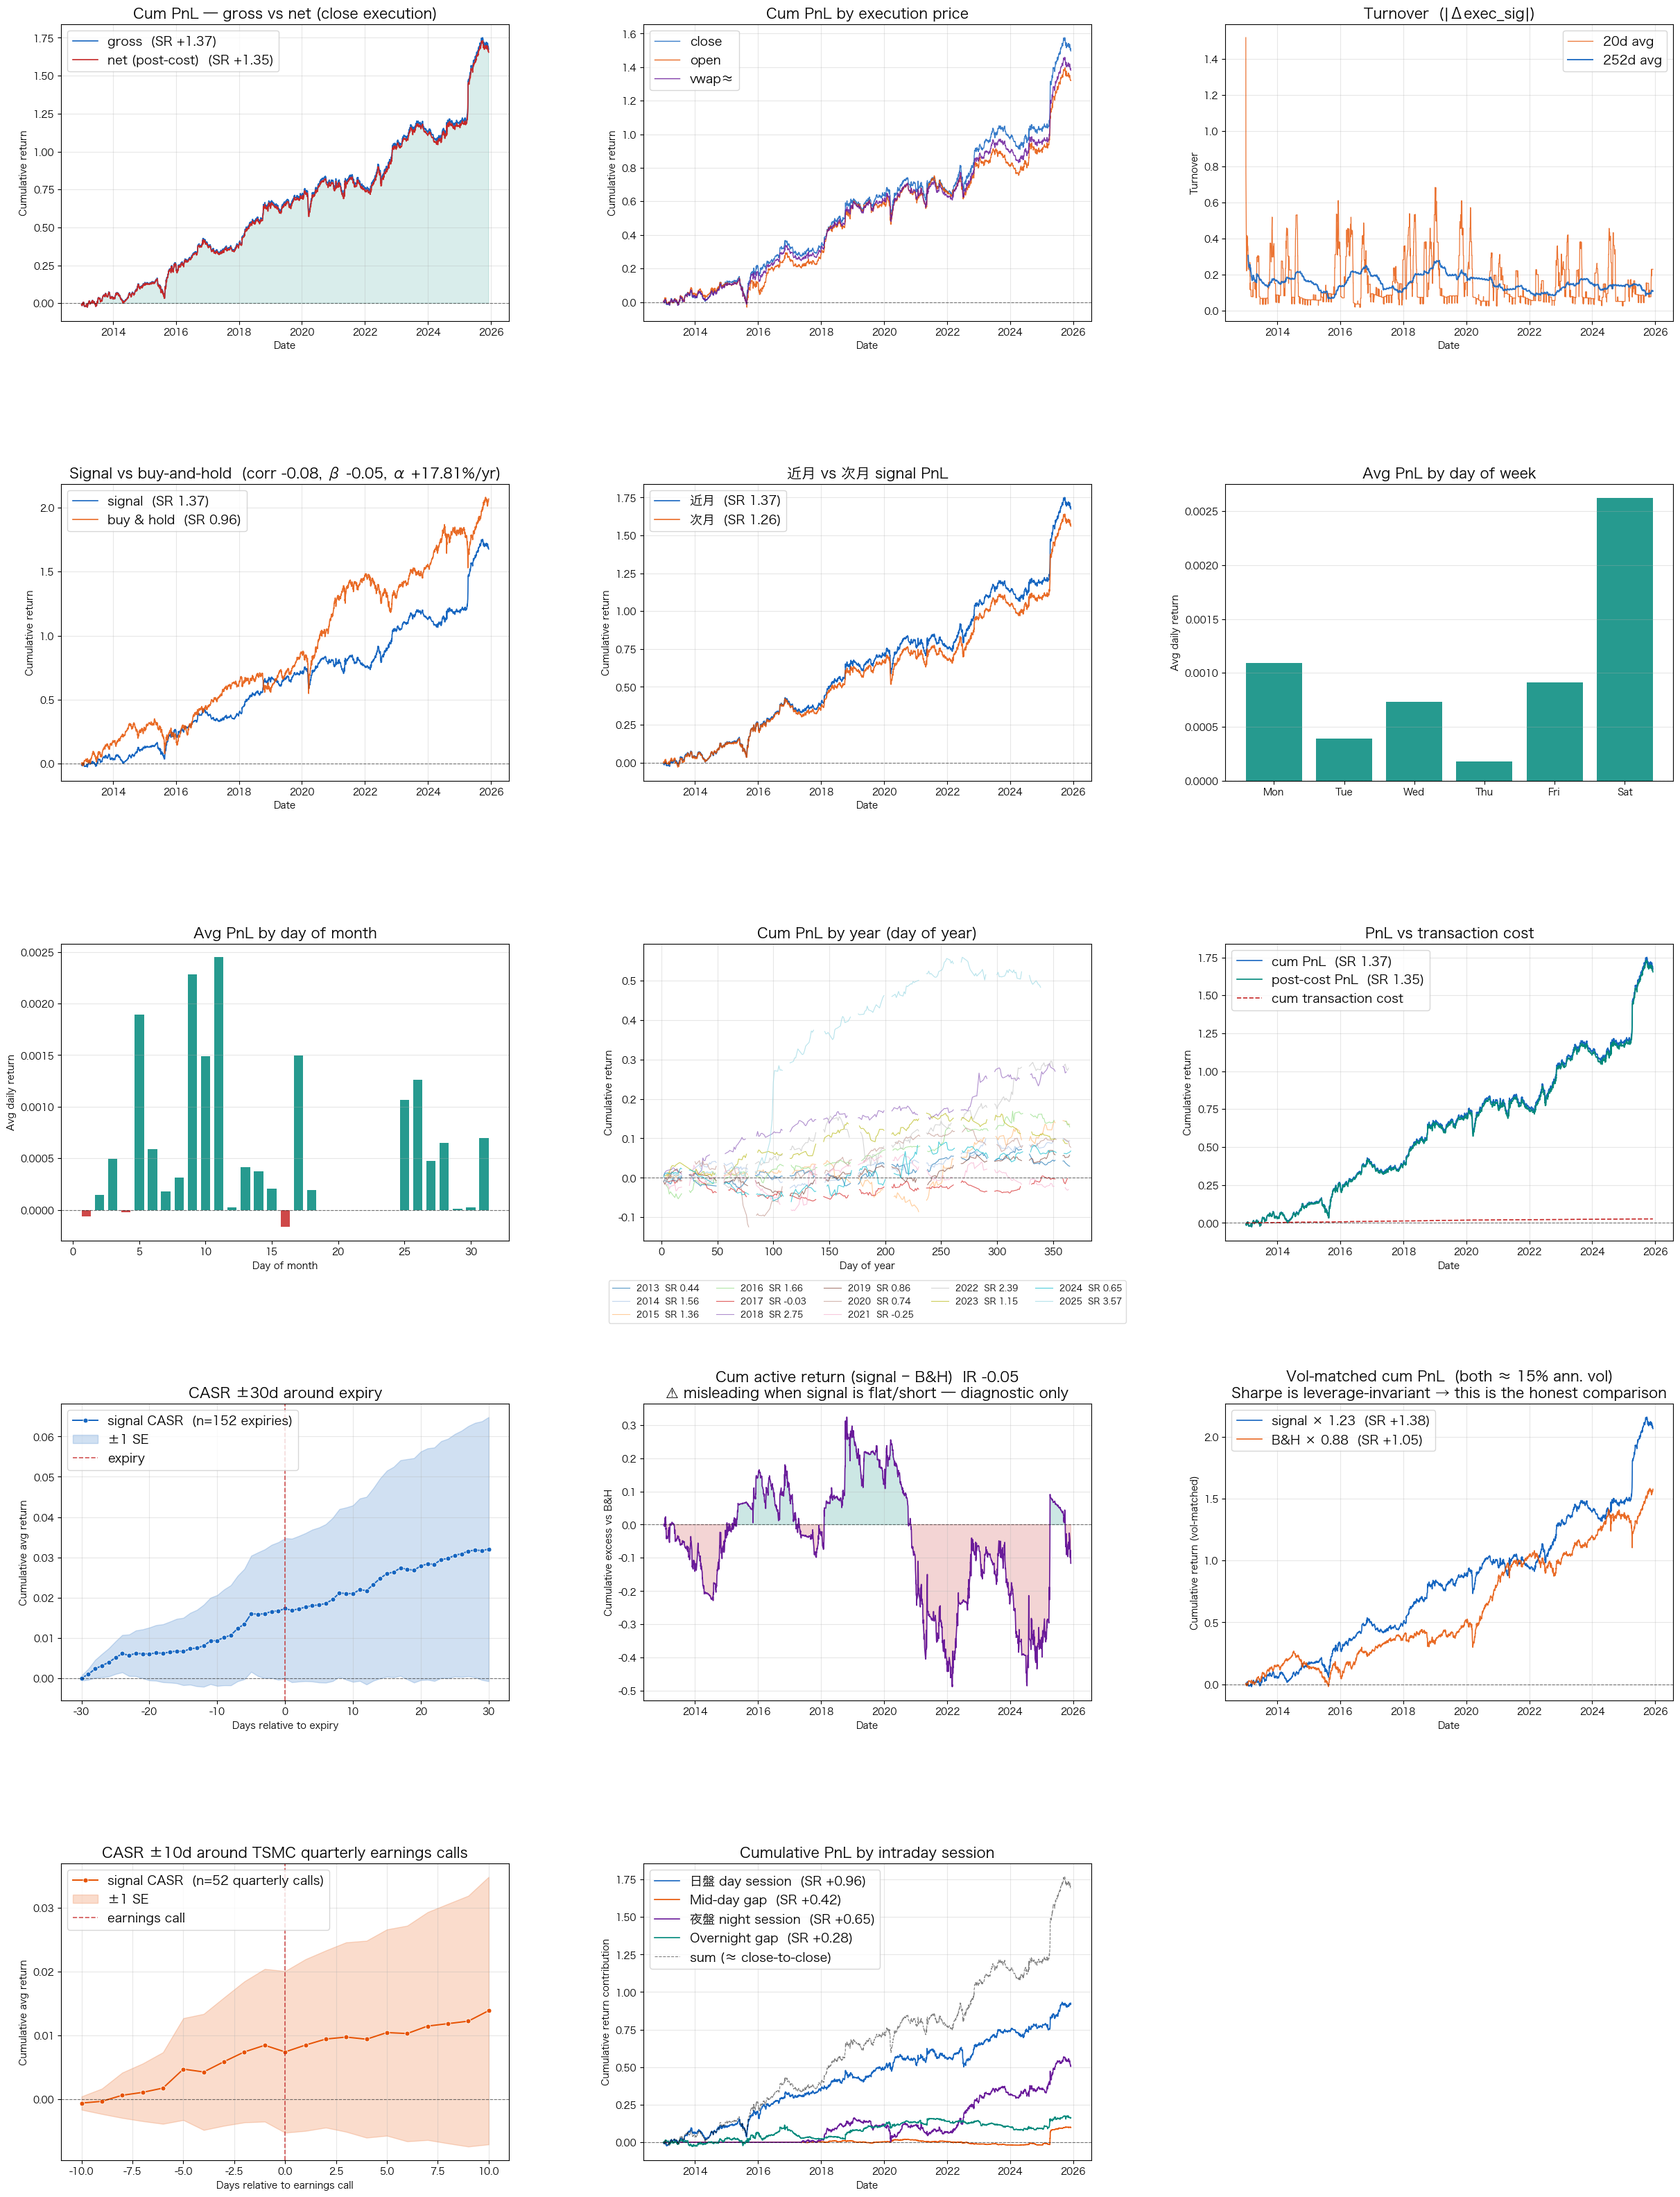


=== carry_rank240_sign   sign=-1   composite=0.921   IS SR_net=+1.07   OOS SR_net=+3.36   OOS/IS=+3.13   beta=-0.124   alpha=+19.28% ===


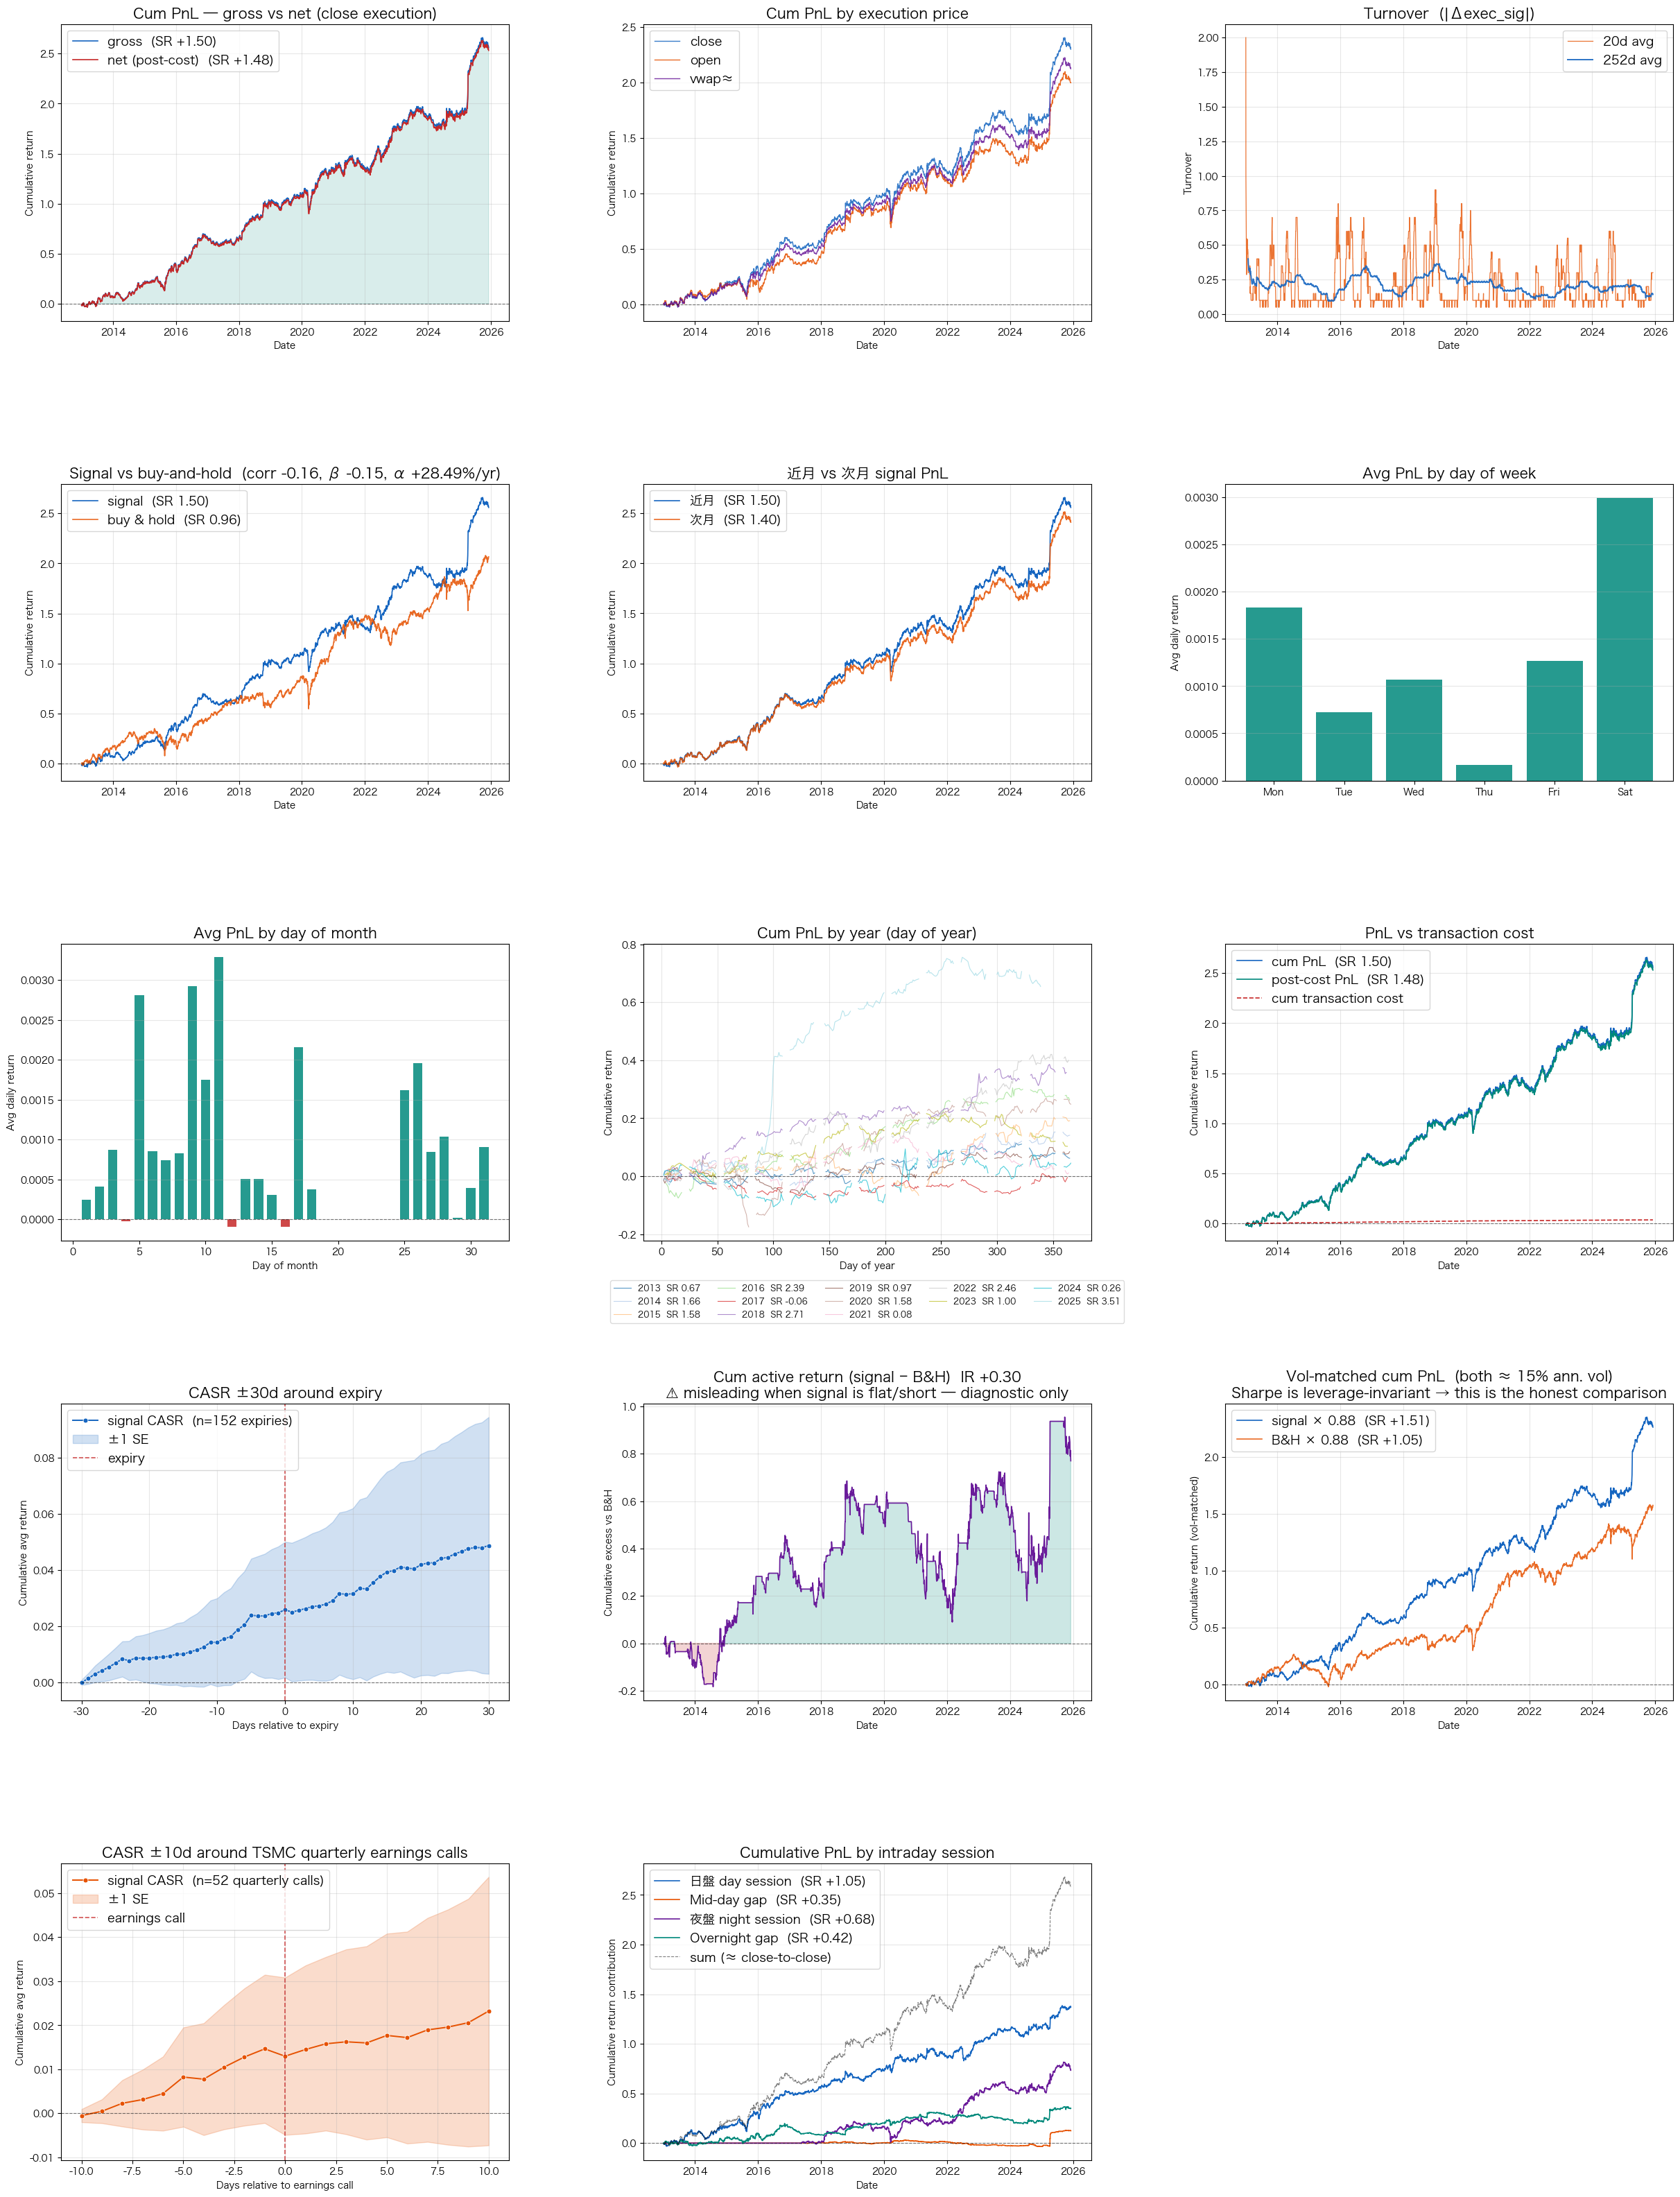


=== carry_rank240   sign=-1   composite=0.919   IS SR_net=+0.88   OOS SR_net=+3.08   OOS/IS=+3.50   beta=-0.089   alpha=+10.26% ===


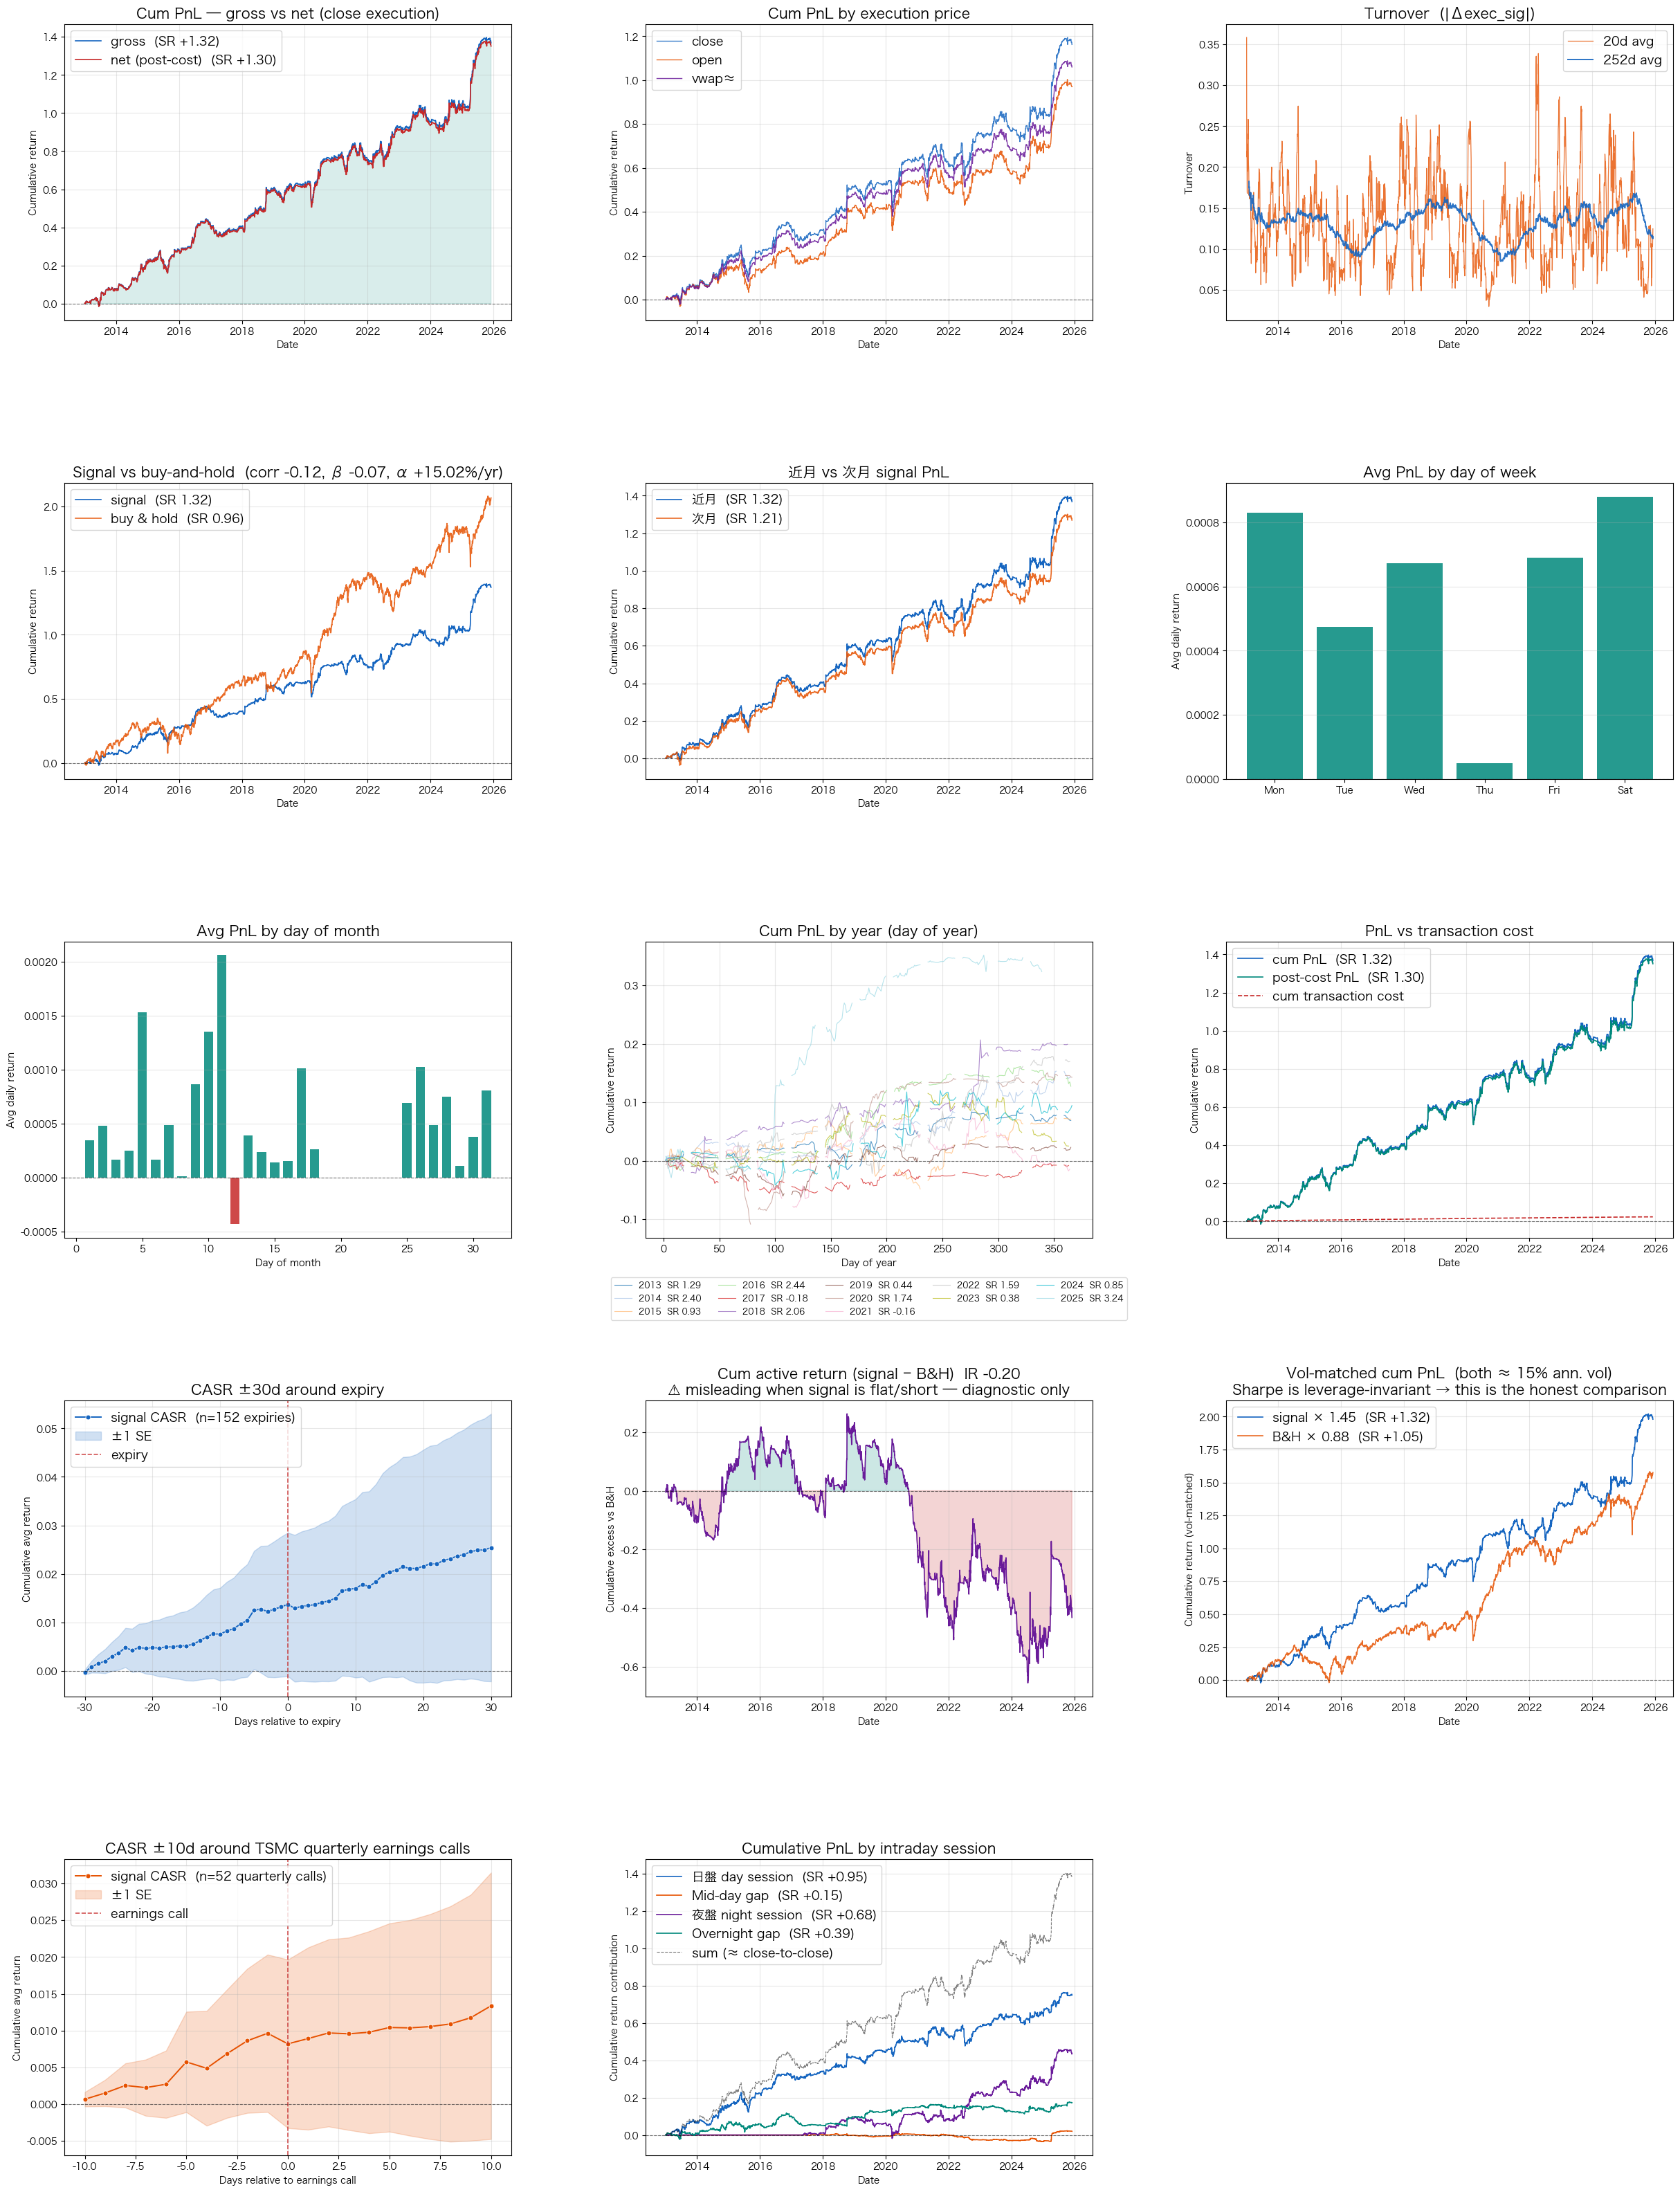

In [10]:
# Full 5×3 dashboards on the beta-neutral top signals.
BETA_MAX = 0.15
scored_bn = scored[scored["beta"].abs() <= BETA_MAX]

cta.set_date_range(start_date=IN_SAMPLE_START, end_date=OOS_END)
TOP_N_DASH = min(5, len(scored_bn))
for nm in scored_bn.head(TOP_N_DASH).index:
    sign = int(scored_bn.loc[nm, "sign"])
    r = scored_bn.loc[nm]
    print(f"\n=== {nm}   sign={sign:+d}   composite={r['composite_score']:.3f}   "
          f"IS SR_net={r['SR_net']:+.2f}   OOS SR_net={r['SR_net_oos']:+.2f}   "
          f"OOS/IS={r['oos_is_ratio']:+.2f}   beta={r['beta']:+.3f}   "
          f"alpha={r['alpha_ann_pct']:+.2f}% ===")
    cta.Simulate(SIGNALS[nm] * sign, time_granularity="1d", normalize=False)